# Notebook 03 - Feature Engineering & Data Preparation
**Proyek:** Pulsevera - Predict, Prevent, Prevail  
**Tujuan:** Membuat fitur baru berbasis domain knowledge kesehatan, validasi kesiapan data, dan melakukan train-test split untuk AI Engineer.

---

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path('..')
PROCESSED_DATA_PATH = BASE_DIR / 'data' / 'processed' / 'dataset_cleaned.csv'
FINAL_DIR = BASE_DIR / 'data' / 'final'
FIGURES_DIR = BASE_DIR / 'notebooks' / 'figures'

df = pd.read_csv(PROCESSED_DATA_PATH)
print(f'Dataset loaded: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')

Dataset loaded: (445132, 41)
Kolom: ['Sex', 'GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'HighRiskLastYear', 'CovidPos', 'Race_Black only, Non-Hispanic', 'Race_Hispanic', 'Race_Multiracial, Non-Hispanic', 'Race_Other race only, Non-Hispanic', 'Race_White only, Non-Hispanic']


---
## Feature Engineering
Membuat fitur baru berbasis domain knowledge risiko penyakit jantung.

In [2]:
# --- Fitur 1: IsActiveSmoker ---
# Perokok aktif (status 2 atau 3 = current smoker) vs tidak
if 'SmokerStatus' in df.columns:
    df['IsActiveSmoker'] = (df['SmokerStatus'] >= 2).astype(int)
    print(f'IsActiveSmoker - distribusi: {df["IsActiveSmoker"].value_counts().to_dict()}')

IsActiveSmoker - distribusi: {0: 395191, 1: 49941}


In [3]:
# --- Fitur 2: IsObese ---
# BMI >= 30 dianggap obesitas
if 'BMI' in df.columns:
    df['IsObese'] = (df['BMI'] >= 30).astype(int)
    print(f'IsObese - distribusi: {df["IsObese"].value_counts().to_dict()}')

IsObese - distribusi: {0: 312555, 1: 132577}


In [4]:
# --- Fitur 3: IsSleepDeprived ---
# Kurang tidur: < 6 jam per malam (rekomendasi WHO: 7-9 jam)
if 'SleepHours' in df.columns:
    df['IsSleepDeprived'] = (df['SleepHours'] < 6).astype(int)
    print(f'IsSleepDeprived - distribusi: {df["IsSleepDeprived"].value_counts().to_dict()}')

IsSleepDeprived - distribusi: {0: 396614, 1: 48518}


In [5]:
# --- Fitur 4: LifestyleRiskScore ---
# Skor komposit gaya hidup berisiko (0-5)
lifestyle_components = []

if 'IsActiveSmoker' in df.columns:
    lifestyle_components.append(df['IsActiveSmoker'])
if 'PhysicalActivities' in df.columns:
    lifestyle_components.append((df['PhysicalActivities'] == 0).astype(int))
if 'AlcoholDrinkers' in df.columns:
    lifestyle_components.append(df['AlcoholDrinkers'])
if 'IsSleepDeprived' in df.columns:
    lifestyle_components.append(df['IsSleepDeprived'])
if 'IsObese' in df.columns:
    lifestyle_components.append(df['IsObese'])

if lifestyle_components:
    df['LifestyleRiskScore'] = sum(lifestyle_components)
    print(f'LifestyleRiskScore - distribusi:')
    print(df['LifestyleRiskScore'].value_counts().sort_index())
    print(f'\nMean: {df["LifestyleRiskScore"].mean():.2f}')
    print(f'Max komponen: {len(lifestyle_components)}')

LifestyleRiskScore - distribusi:
LifestyleRiskScore
0     73975
1    202842
2    121113
3     39451
4      7195
5       556
Name: count, dtype: int64

Mean: 1.34
Max komponen: 5


In [6]:
# --- Fitur 5: HasChronicCondition ---
# Apakah memiliki salah satu kondisi kronis relevan
chronic_cols = ['HadDiabetes', 'HadStroke', 'HadAsthma', 'HadCOPD', 'HadKidneyDisease']
chronic_cols = [c for c in chronic_cols if c in df.columns]

if chronic_cols:
    df['HasChronicCondition'] = (df[chronic_cols].sum(axis=1) > 0).astype(int)
    print(f'HasChronicCondition - distribusi: {df["HasChronicCondition"].value_counts().to_dict()}')

HasChronicCondition - distribusi: {0: 296026, 1: 149106}


In [7]:
# --- Fitur 6: PoorHealthDays_Total ---
# Total hari tidak sehat (fisik + mental)
if all(c in df.columns for c in ['PhysicalHealthDays', 'MentalHealthDays']):
    df['PoorHealthDays_Total'] = df['PhysicalHealthDays'] + df['MentalHealthDays']
    print(f'PoorHealthDays_Total - stats:')
    print(df['PoorHealthDays_Total'].describe().round(2))

PoorHealthDays_Total - stats:
count    445132.00
mean          4.37
std           5.46
min           0.00
25%           0.00
50%           2.00
75%           7.50
max          17.50
Name: PoorHealthDays_Total, dtype: float64


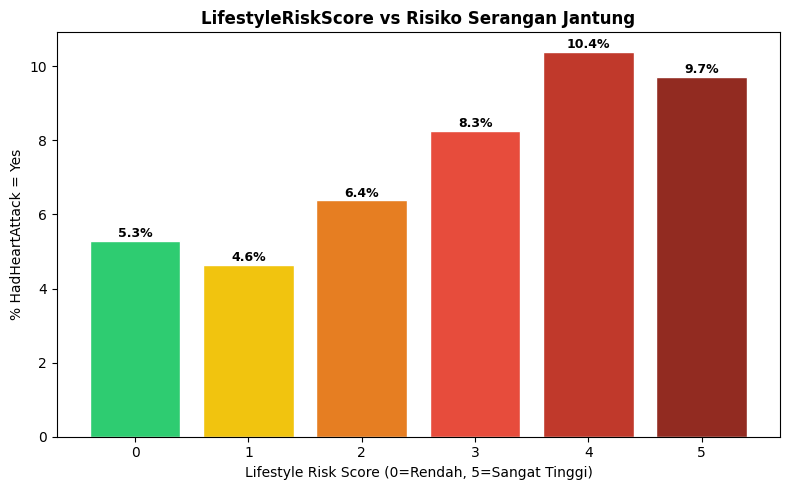

In [8]:
# Visualisasi: LifestyleRiskScore vs HadHeartAttack
if 'LifestyleRiskScore' in df.columns:
    risk_by_score = df.groupby('LifestyleRiskScore')['HadHeartAttack'].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(risk_by_score.index, risk_by_score.values,
           color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#922b21'][:len(risk_by_score)],
           edgecolor='white')
    ax.set_title('LifestyleRiskScore vs Risiko Serangan Jantung', fontsize=12, fontweight='bold')
    ax.set_xlabel('Lifestyle Risk Score (0=Rendah, 5=Sangat Tinggi)')
    ax.set_ylabel('% HadHeartAttack = Yes')
    for i, (score, pct) in enumerate(risk_by_score.items()):
        ax.text(score, pct + 0.1, f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'lifestyle_risk_score.png', dpi=150)
    plt.show()

In [9]:
# Korelasi fitur baru dengan target
new_features = ['IsActiveSmoker', 'IsObese', 'IsSleepDeprived', 'LifestyleRiskScore',
                'HasChronicCondition', 'PoorHealthDays_Total']
new_features = [f for f in new_features if f in df.columns]

print('=== KORELASI FITUR BARU DENGAN HadHeartAttack ===')
for feat in new_features:
    corr = df[feat].corr(df['HadHeartAttack'])
    print(f'{feat:30s}: {corr:+.4f}')

=== KORELASI FITUR BARU DENGAN HadHeartAttack ===
IsActiveSmoker                : +0.0413
IsObese                       : +0.0301
IsSleepDeprived               : +0.0414
LifestyleRiskScore            : +0.0459
HasChronicCondition           : +0.1632
PoorHealthDays_Total          : +0.0692


---
## Validasi Kesiapan Data untuk Model

In [10]:
print('=== CHECKLIST VALIDASI DATA ===')

# Cek 1: No missing values
total_missing = df.isnull().sum().sum()
print(f'[{"OK" if total_missing == 0 else "FAIL"}] Missing values: {total_missing}')

# Cek 2: Semua kolom numerik
obj_cols = df.select_dtypes(include='object').columns.tolist()
print(f'[{"OK" if len(obj_cols) == 0 else "FAIL"}] Kolom object: {obj_cols if obj_cols else "Tidak ada"}')

# Cek 3: Target binary 0/1
target_vals = df['HadHeartAttack'].unique()
is_binary = set(target_vals).issubset({0, 1})
print(f'[{"OK" if is_binary else "FAIL"}] Target binary: {sorted(target_vals)}')

# Cek 4: No infinite values
inf_count = np.isinf(df.select_dtypes(include='number')).sum().sum()
print(f'[{"OK" if inf_count == 0 else "FAIL"}] Infinite values: {inf_count}')

print(f'\nShape final: {df.shape}')

=== CHECKLIST VALIDASI DATA ===
[OK] Missing values: 0
[OK] Kolom object: Tidak ada
[OK] Target binary: [np.int64(0), np.int64(1)]
[OK] Infinite values: 0

Shape final: (445132, 47)


In [11]:
# Train-Test Split (stratified, 80:20)
X = df.drop(columns=['HadHeartAttack'])
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train distribusi:')
print(y_train.value_counts(normalize=True).rename({0: 'No', 1: 'Yes'}))
print(f'y_test distribusi:')
print(y_test.value_counts(normalize=True).rename({0: 'No', 1: 'Yes'}))
print('\nStratified split menjaga proporsi class yang sama di train dan test.')

X_train: (356105, 46)
X_test : (89027, 46)
y_train distribusi:
HadHeartAttack
No     0.943595
Yes    0.056405
Name: proportion, dtype: float64
y_test distribusi:
HadHeartAttack
No     0.94359
Yes    0.05641
Name: proportion, dtype: float64

Stratified split menjaga proporsi class yang sama di train dan test.


In [12]:
# Simpan ke data/final/
X_train.to_csv(FINAL_DIR / 'X_train.csv', index=False)
X_test.to_csv(FINAL_DIR / 'X_test.csv', index=False)
y_train.to_csv(FINAL_DIR / 'y_train.csv', index=False)
y_test.to_csv(FINAL_DIR / 'y_test.csv', index=False)

# Simpan juga full dataset dengan fitur baru
df.to_csv(FINAL_DIR / 'dataset_final.csv', index=False)

print('File tersimpan:')
for f in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv', 'dataset_final.csv']:
    path = FINAL_DIR / f
    print(f'  {path} ({path.stat().st_size / 1024**2:.1f} MB)')

File tersimpan:
  ..\data\final\X_train.csv (46.0 MB)
  ..\data\final\X_test.csv (11.5 MB)
  ..\data\final\y_train.csv (1.0 MB)
  ..\data\final\y_test.csv (0.3 MB)
  ..\data\final\dataset_final.csv (58.4 MB)


In [13]:
# Summary fitur baru untuk data_dictionary
print('=== FITUR BARU (untuk data_dictionary.md) ===')
new_feat_info = [
    ('IsActiveSmoker', 'int', 'Perokok aktif saat ini (SmokerStatus >= 2)', '0, 1', '0%', 'Binary dari SmokerStatus'),
    ('IsObese', 'int', 'Indikator obesitas (BMI >= 30)', '0, 1', '0%', 'Binary dari BMI'),
    ('IsSleepDeprived', 'int', 'Kurang tidur (< 6 jam)', '0, 1', '0%', 'Binary dari SleepHours'),
    ('LifestyleRiskScore', 'int', 'Skor risiko gaya hidup (0-5)', '0-5', '0%', 'Kombinasi 5 faktor gaya hidup'),
    ('HasChronicCondition', 'int', 'Memiliki minimal 1 kondisi kronis', '0, 1', '0%', 'OR dari kolom penyakit kronis'),
    ('PoorHealthDays_Total', 'float', 'Total hari tidak sehat (fisik+mental)', 'Numerik', '0%', 'Sum PhysicalHealthDays + MentalHealthDays'),
]
for row in new_feat_info:
    print(f'| {row[0]} | {row[1]} | {row[2]} | {row[3]} | {row[4]} | {row[5]} |')

=== FITUR BARU (untuk data_dictionary.md) ===
| IsActiveSmoker | int | Perokok aktif saat ini (SmokerStatus >= 2) | 0, 1 | 0% | Binary dari SmokerStatus |
| IsObese | int | Indikator obesitas (BMI >= 30) | 0, 1 | 0% | Binary dari BMI |
| IsSleepDeprived | int | Kurang tidur (< 6 jam) | 0, 1 | 0% | Binary dari SleepHours |
| LifestyleRiskScore | int | Skor risiko gaya hidup (0-5) | 0-5 | 0% | Kombinasi 5 faktor gaya hidup |
| HasChronicCondition | int | Memiliki minimal 1 kondisi kronis | 0, 1 | 0% | OR dari kolom penyakit kronis |
| PoorHealthDays_Total | float | Total hari tidak sehat (fisik+mental) | Numerik | 0% | Sum PhysicalHealthDays + MentalHealthDays |
